# *******Rezvan *******

# Libraries

In [2]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os


# Data Path and Loading

In [3]:
DATA_DIR = Path("../data/eye_tracking")

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

[WindowsPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), WindowsPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]
(384510, 61)


# Estimate Sampling Rate

In [4]:
t = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
dt_ns = t.diff().dropna()

median_dt_ns = dt_ns.median()
sampling_rate_hz = 1e9 / median_dt_ns

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ns:.0f} ns")
print(f"Median sample interval: {median_dt_ns / 1e6:.3f} ms")

Estimated sampling rate: 199.98 Hz
Median sample interval: 5000600 ns
Median sample interval: 5.001 ms


In [34]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df = add_time_per_model(df, time_col="gaze_capture_time")

seg = (
    df[(df["condition_number"] == 1) &
             (df["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

seg["dt_ms"] = seg["time_ms"].diff()
print(seg.loc[545:555, ["time_ms", "dt_ms", "left_status", "right_status", "frame_number"]].to_string())

       time_ms     dt_ms  left_status right_status  frame_number
545  2726.3392    5.0030  Compensated  Compensated        585037
546  2731.3395    5.0003      Tracked  Compensated        585038
547  2736.3398    5.0003      Tracked  Compensated        585039
548  2741.3438    5.0040      Tracked  Compensated        585040
549  2746.3452    5.0014      Tracked  Compensated        585041
550  2751.3466    5.0014      Tracked  Compensated        585042
551  2761.3458    9.9992      Tracked      Invalid        585044
552  2966.3697  205.0239  Compensated      Invalid        585085
553  3006.3741   40.0044      Invalid      Visible        585093
554  3171.3989  165.0248      Visible      Invalid        585126
555  3176.4017    5.0028      Visible      Invalid        585127


# Preprocessing Function

In [5]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

df_clean = cleaning_function(df)
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02


# Time Function

In [6]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


# a gap check

In [29]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

seg["dt_ms"] = seg["time_ms"].diff()
print(seg.loc[545:555, ["time_ms", "dt_ms", "left_status", "right_status", "frame_number"]].to_string())

       time_ms     dt_ms  left_status right_status  frame_number
545  2726.3392    5.0030  Compensated  Compensated        585037
546  2731.3395    5.0003      Tracked  Compensated        585038
547  2736.3398    5.0003      Tracked  Compensated        585039
548  2741.3438    5.0040      Tracked  Compensated        585040
549  2746.3452    5.0014      Tracked  Compensated        585041
550  2751.3466    5.0014      Tracked  Compensated        585042
551  2761.3458    9.9992      Tracked      Invalid        585044
552  2966.3697  205.0239  Compensated      Invalid        585085
553  3006.3741   40.0044      Invalid      Visible        585093
554  3171.3989  165.0248      Visible      Invalid        585126
555  3176.4017    5.0028      Visible      Invalid        585127


# Define Valid Samples and Interpolation

In [14]:
# SETTINGS

# Maximum duration of a bad interval that we still allow
# ourselves to interpolate.
# Example: if a bad gap lasts 180 ms, interpolate it.
# If it lasts 400 ms, keep it as missing.
MAX_INTERP_MS = 250.0

# These are the gaze-direction columns we want to clean.
# They form one 3D gaze vector per sample.
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]


# 1) DEFINE WHICH SAMPLES ARE GOOD
def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    """
    Decide whether each sample is GOOD or BAD.

    A sample is GOOD if:
      - at least one eye is tracked
      - OR both eyes are compensated

    Why this rule?
    --------------
    - If at least one eye is tracked, we still have usable eye-tracking input.
    - If both eyes are compensated, we also keep the sample.
    - Everything else is treated as BAD.

    Returns
    -------
    np.ndarray of bool
        True  = good sample
        False = bad sample
    """
    # Standardize the text so comparisons are robust
    # (e.g. "Tracked", " tracked ", etc. all become "tracked")
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    # Check tracking state for each eye
    l_tr = (l == "tracked")
    r_tr = (r == "tracked")
    l_cp = (l == "compensated")
    r_cp = (r == "compensated")

    # GOOD if:
    # - left OR right eye is tracked
    # - OR both eyes are compensated
    return ((l_tr | r_tr) | (l_cp & r_cp)).to_numpy(dtype=bool)


# 2) FIND CONTIGUOUS BAD INTERVALS
def find_runs(mask: np.ndarray):
    """
    Return list of (start, end) index pairs for contiguous True runs.

    Example
    -------
    mask = [False, True, True, False, True]
    output = [(1, 2), (4, 4)]

    Meaning
    -------
    - One True-run starts at index 1 and ends at index 2
    - Another True-run starts and ends at index 4
    """
    mask = np.asarray(mask, dtype=bool)


    idx = np.flatnonzero(mask)

    # If there are no True values, there are no runs
    if len(idx) == 0:
        return []

    runs = []

    # Start the first run at the first True index
    start = prev = idx[0]

    # Go through the remaining True indices
    for k in idx[1:]:
        # If the current index is directly after the previous one,
        # we are still inside the same run
        if k == prev + 1:
            prev = k
        else:
            # Otherwise, the previous run ended at 'prev'
            runs.append((start, prev))

            # Start a new run at the current index
            start = prev = k

    # Add the final run
    runs.append((start, prev))
    return runs


# 3) NORMALIZE 3D GAZE VECTORS
def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    """
    Normalize each row of a (n, 3) array to unit length.

    Why this is needed
    ------------------
    We interpolate x, y, z separately.
    After interpolation, the resulting 3D vector may no longer have length 1.
    Since gaze direction is a direction vector, we normalize it back to unit length.

    Rows with NaNs or zero-length vectors remain NaN.
    """
    xyz = np.asarray(xyz, dtype=float)

    # Compute vector norm row by row
    nrm = np.linalg.norm(xyz, axis=1)

    # Prepare output filled with NaN by default
    out = np.full_like(xyz, np.nan, dtype=float)

    # A row can be normalized only if:
    # - its norm is finite
    # - its norm is > 0
    # - all components are finite
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)

    # Normalize only valid rows
    out[good] = xyz[good] / nrm[good, None]
    return out


# 4) INTERPOLATE ONE SEGMENT
def interpolate_segment(
    sub: pd.DataFrame,
    forward_cols=FORWARD_COLS,
    max_interp_ms: float = MAX_INTERP_MS
) -> pd.DataFrame:

    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)
    is_rejected = np.zeros(n, dtype=bool)

    # Start from original data, but immediately blank all bad samples
    clean = xyz.copy()
    clean[bad, :] = np.nan

    for a, b in bad_runs:
        left = a - 1
        right = b + 1

        dur_ms = t[b] - t[a]

        bracketed = (
            left >= 0 and
            right < n and
            good[left] and
            good[right]
        )

        finite_bounds = (
            bracketed and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if finite_bounds and (dur_ms <= max_interp_ms):
            # Fill the previously blanked bad run
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            # Normalize only the rows we just interpolated
            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])

            is_interpolated[a:b+1] = True
        else:
            # Keep them as NaN
            is_rejected[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated
    sub["is_rejected"] = is_rejected

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


# 5) APPLY TO ALL TRIALS / SEGMENTS
def interpolate_all_segments(
    df: pd.DataFrame,
    max_interp_ms: float = MAX_INTERP_MS
) -> pd.DataFrame:
    """
    Apply interpolation separately to each
    (condition_number, trial_number) segment.

    Why separate by segment?
    ------------------------
    Because interpolation should happen only within a trial,
    never across trials.
    """
    out = []

    grouped = df.groupby(["condition_number", "trial_number"], sort=True)

    for (cond, trial), sub in grouped:
        cleaned = interpolate_segment(
            sub,
            forward_cols=FORWARD_COLS,
            max_interp_ms=max_interp_ms
        )

        # Helpful label for later QC / plotting
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    # Combine all cleaned segments back together
    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )


# 6) RUN THE INTERPOLATION
df_clean = interpolate_all_segments(df_clean, max_interp_ms=MAX_INTERP_MS)


# 7) QUALITY-CONTROL SUMMARY
qc = (
    df_clean.groupby(["condition_number", "trial_number"])
      .agg(
          n_samples=("time_ms", "size"),
          n_bad=("bad_sample", "sum"),
          n_interpolated=("is_interpolated", "sum"),
          n_rejected=("is_rejected", "sum"),
      )
      .reset_index()
)

# Convert counts into percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]
qc["pct_rejected"] = 100 * qc["n_rejected"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  n_rejected  pct_bad  pct_interpolated  pct_rejected
                1             1       4001     74              68           6 1.849538          1.699575      0.149963
                1             2      21653    126              94          32 0.581906          0.434120      0.147786
                1             3      10276    114              99          15 1.109381          0.963410      0.145971
                1             4      12824    239             128         111 1.863693          0.998129      0.865565
                1             5       4651    123             123           0 2.644593          2.644593      0.000000
                1             6      15074    201             122          79 1.333422          0.809341      0.524081
                2             1      10647    127              73          54 1.192824          0.685639      0.507185
                2             2       3546     5

# Sorting

In [8]:
df_clean = df_clean.sort_values(["condition_number", "trial_number", "gaze_capture_time"])
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000325398422099900,1773140944969,41.12195,2.000000,525251,0.293504,Valid,0.012164,-0.266522,0.963752,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
1,1000325398427100300,1773140944973,41.12195,2.000000,525252,0.315788,Valid,0.013124,-0.265512,0.964018,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
2,1000325398432112600,1773140944973,41.12195,2.000000,525253,0.354264,Valid,0.014052,-0.264599,0.964256,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
3,1000325398437113000,1773140944973,41.12195,2.000000,525254,0.441358,Valid,0.014769,-0.263616,0.964515,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
4,1000325398442101200,1773140944973,41.12195,2.000000,525255,0.473352,Valid,0.015610,-0.262661,0.964762,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384505,1000328184386556900,1773143730444,1607.74300,1.276645,1082229,1.000000,Valid,-0.036495,0.168651,0.985000,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384506,1000328184391558700,1773143730454,1607.75400,1.277654,1082230,0.998679,Valid,-0.036406,0.169091,0.984928,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384507,1000328184396558500,1773143730454,1607.75400,1.278499,1082231,0.993781,Valid,-0.036322,0.169536,0.984854,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384508,1000328184401558700,1773143730465,1607.76500,1.277999,1082232,0.982768,Valid,-0.036273,0.170024,0.984772,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02


# Interpolation Check

In [15]:
for comp in ["x", "y", "z"]:
    raw = df_clean[f"gaze_forward_{comp}"].to_numpy(dtype=float)
    clean = df_clean[f"clean_gaze_forward_{comp}"].to_numpy(dtype=float)
    good = df_clean["good_sample"].to_numpy(dtype=bool)

    diff = np.abs(raw - clean)
    print(comp, "max diff on good rows:", np.nanmax(diff[good]))

x max diff on good rows: 0.0
y max diff on good rows: 0.0
z max diff on good rows: 0.0


In [16]:
def plot_interpolation_window(
    df_segment: pd.DataFrame,
    center_start: int,
    center_end: int,
    pad: int = 20,
    component: str = "x"
):
    """
    Plot raw vs cleaned gaze component around one bad/interpolated run.

    Parameters
    ----------
    df_segment : pd.DataFrame
        One segment only (one condition/trial), already interpolated.
    center_start, center_end : int
        Start/end row positions (within df_segment after sorting by time_ms).
    pad : int
        Number of samples to include before/after the run.
    component : {"x", "y", "z"}
        Which gaze component to plot.
    """
    comp_raw = f"gaze_forward_{component}"
    comp_clean = f"clean_gaze_forward_{component}"

    sub = df_segment.sort_values("time_ms").reset_index(drop=True)

    a = max(0, center_start - pad)
    b = min(len(sub) - 1, center_end + pad)

    win = sub.iloc[a:b+1].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(win["time_ms"], win[comp_raw], label=f"raw {comp_raw}")
    plt.plot(win["time_ms"], win[comp_clean], label=f"clean {comp_clean}")

    # shade interpolated points inside this window
    interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
    if interp_mask.any():
        interp_times = win.loc[interp_mask, "time_ms"]
        plt.axvspan(interp_times.min(), interp_times.max(), alpha=0.2, label="interpolated region")

    # optionally also mark rejected points
    rej_mask = win["is_rejected"].fillna(False).to_numpy(dtype=bool)
    if rej_mask.any():
        rej_times = win.loc[rej_mask, "time_ms"]
        plt.axvspan(rej_times.min(), rej_times.max(), alpha=0.15, label="rejected region")

    cond = win["condition_number"].iloc[0]
    trial = win["trial_number"].iloc[0]

    plt.title(f"Condition {cond}, Trial {trial} | component={component}")
    plt.xlabel("time_ms")
    plt.ylabel("gaze value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
def find_interpolated_runs(df_segment: pd.DataFrame):
    """
    Return list of (start_idx, end_idx) for contiguous interpolated runs
    within one segment.
    """
    sub = df_segment.sort_values("time_ms").reset_index(drop=True)
    mask = sub["is_interpolated"].fillna(False).to_numpy(dtype=bool)
    return find_runs(mask)


def plot_all_interpolated_runs_for_trial(
    df: pd.DataFrame,
    condition_number,
    trial_number,
    component: str = "x",
    pad: int = 20
):
    """
    Plot all interpolated runs for one condition/trial.
    """
    seg = (
        df[(df["condition_number"] == condition_number) &
           (df["trial_number"] == trial_number)]
        .sort_values("time_ms")
        .reset_index(drop=True)
    )

    runs = find_interpolated_runs(seg)

    if not runs:
        print(f"No interpolated runs found for condition={condition_number}, trial={trial_number}")
        return

    print(f"Found {len(runs)} interpolated runs")

    for i, (a, b) in enumerate(runs, start=1):
        print(f"Plotting run {i}: rows {a} to {b}")
        plot_interpolation_window(seg, a, b, pad=pad, component=component)

Found 9 interpolated runs
Plotting run 1: rows 552 to 555


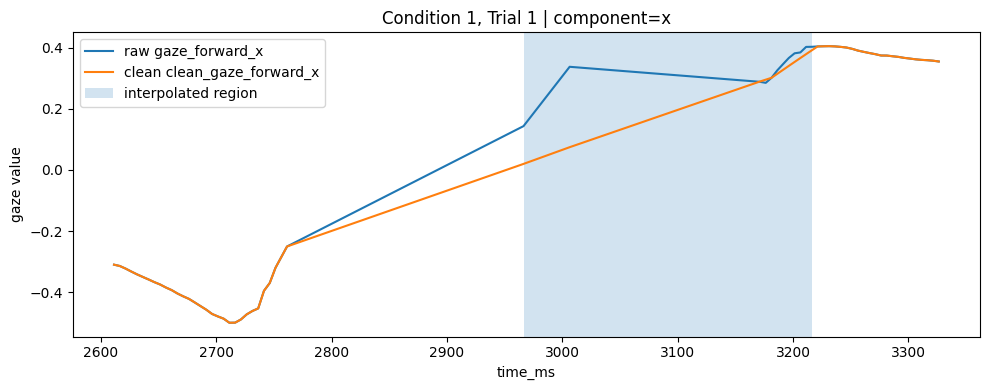

Plotting run 2: rows 557 to 563


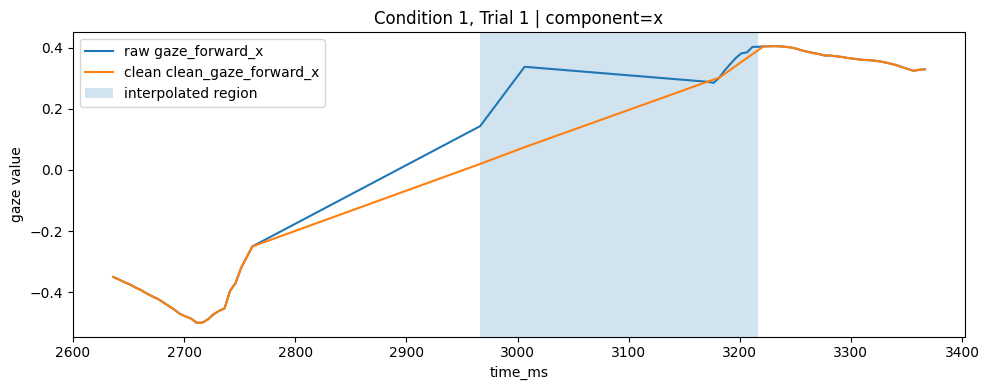

Plotting run 3: rows 1336 to 1352


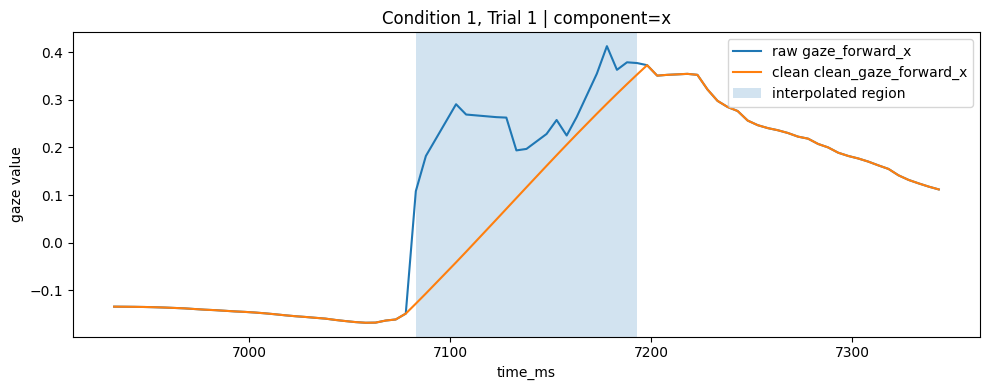

Plotting run 4: rows 2131 to 2140


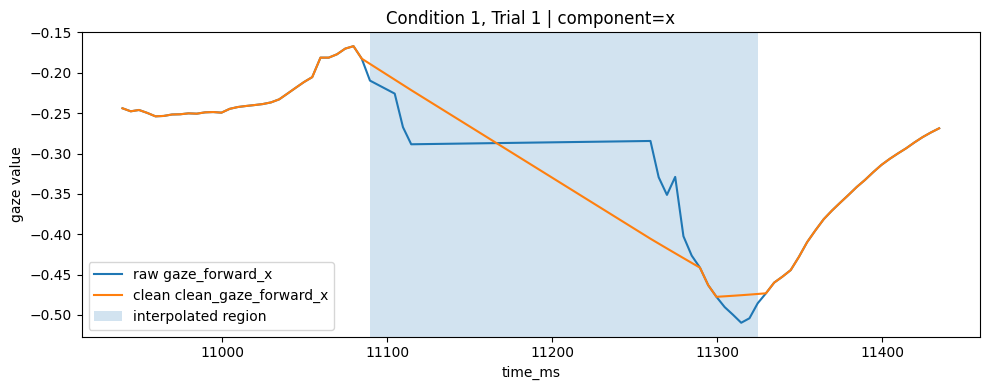

Plotting run 5: rows 2144 to 2148


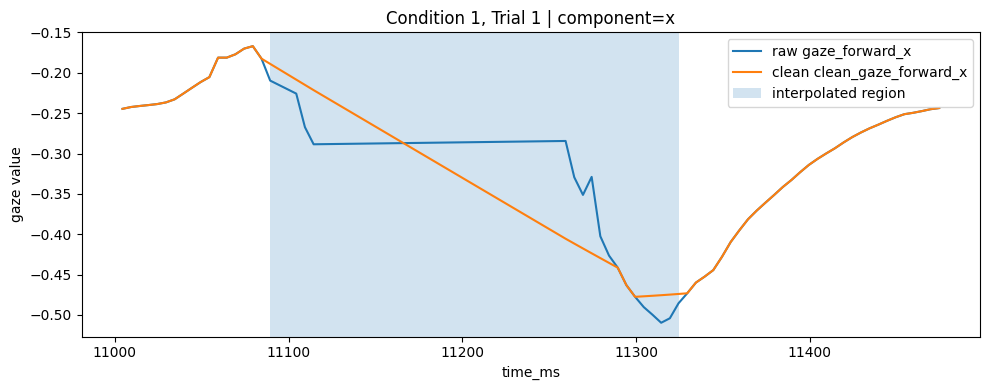

Plotting run 6: rows 2239 to 2250


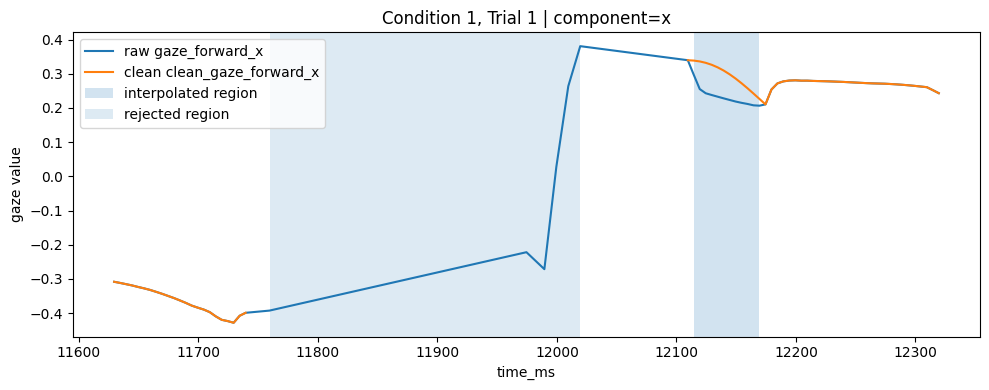

Plotting run 7: rows 2715 to 2717


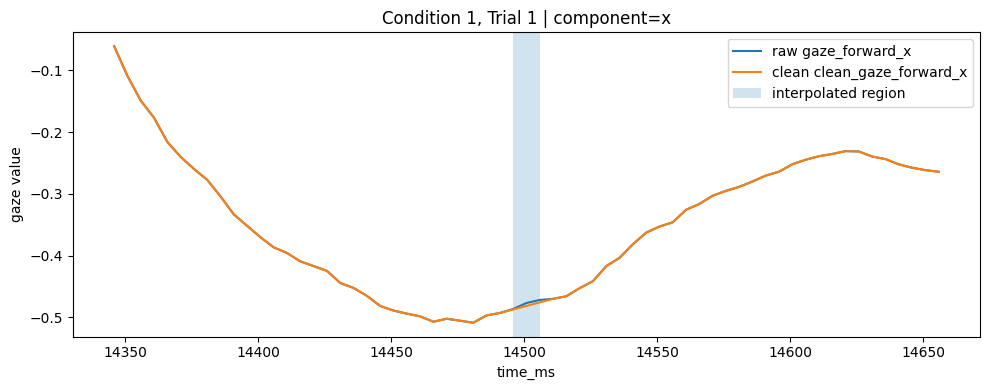

Plotting run 8: rows 3803 to 3808


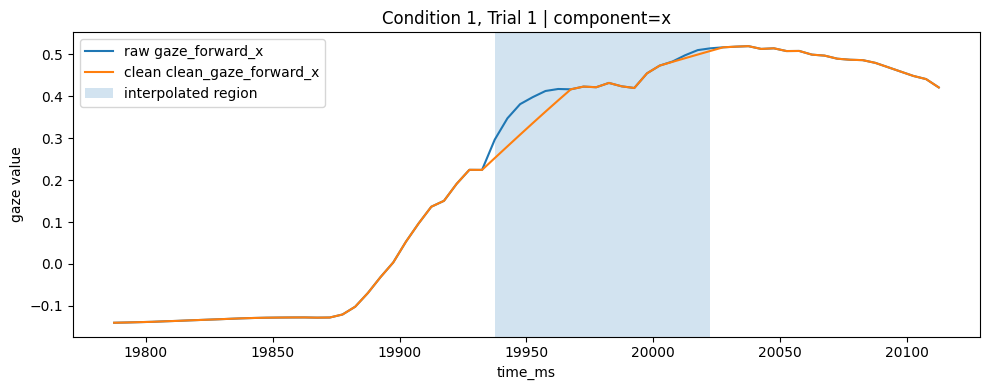

Plotting run 9: rows 3817 to 3820


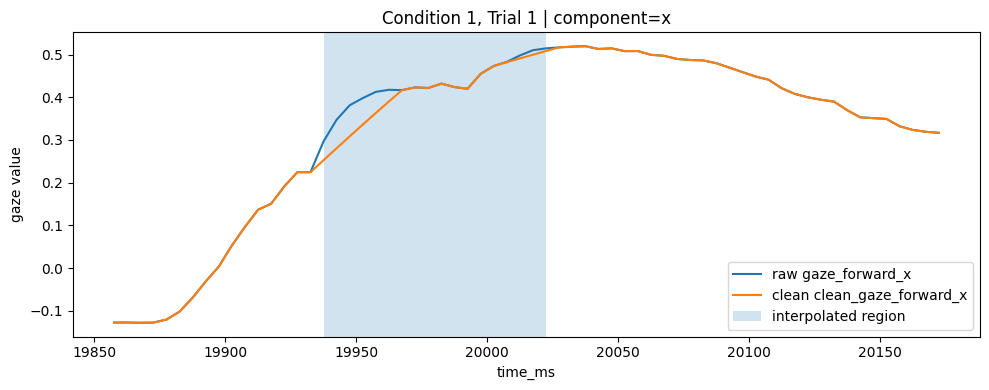

In [26]:
plot_all_interpolated_runs_for_trial(df_clean, condition_number=1, trial_number=1, component="x", pad=30)

In [27]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

bad_runs = find_runs(seg["bad_sample"].to_numpy(dtype=bool))
interp_runs = find_runs(seg["is_interpolated"].to_numpy(dtype=bool))
rej_runs = find_runs(seg["is_rejected"].to_numpy(dtype=bool))

print("bad_runs:", bad_runs)
print("interp_runs:", interp_runs)
print("rej_runs:", rej_runs)

bad_runs: [(np.int64(552), np.int64(555)), (np.int64(557), np.int64(563)), (np.int64(1336), np.int64(1352)), (np.int64(2131), np.int64(2140)), (np.int64(2144), np.int64(2148)), (np.int64(2232), np.int64(2237)), (np.int64(2239), np.int64(2250)), (np.int64(2715), np.int64(2717)), (np.int64(3803), np.int64(3808)), (np.int64(3817), np.int64(3820))]
interp_runs: [(np.int64(552), np.int64(555)), (np.int64(557), np.int64(563)), (np.int64(1336), np.int64(1352)), (np.int64(2131), np.int64(2140)), (np.int64(2144), np.int64(2148)), (np.int64(2239), np.int64(2250)), (np.int64(2715), np.int64(2717)), (np.int64(3803), np.int64(3808)), (np.int64(3817), np.int64(3820))]
rej_runs: [(np.int64(2232), np.int64(2237))]


In [28]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 1)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

check = seg.loc[540:560, [
    "time_ms",
    "gaze_forward_x",
    "clean_gaze_forward_x",
    "bad_sample",
    "is_interpolated",
    "is_rejected"
]]

print(check.to_string())

       time_ms  gaze_forward_x  clean_gaze_forward_x  bad_sample  is_interpolated  is_rejected
540  2701.3415       -0.479043             -0.479043       False            False        False
541  2706.3411       -0.486337             -0.486337       False            False        False
542  2711.3425       -0.499745             -0.499745       False            False        False
543  2716.3421       -0.499394             -0.499394       False            False        False
544  2721.3362       -0.489066             -0.489066       False            False        False
545  2726.3392       -0.472450             -0.472450       False            False        False
546  2731.3395       -0.461267             -0.461267       False            False        False
547  2736.3398       -0.452811             -0.452811       False            False        False
548  2741.3438       -0.395280             -0.395280       False            False        False
549  2746.3452       -0.369746             -0.3697

In [19]:
def plot_interpolation_xyz(
    df_segment: pd.DataFrame,
    center_start: int,
    center_end: int,
    pad: int = 20
):
    """
    Plot raw vs cleaned x/y/z around one interpolated run.
    """
    sub = df_segment.sort_values("time_ms").reset_index(drop=True)

    a = max(0, center_start - pad)
    b = min(len(sub) - 1, center_end + pad)
    win = sub.iloc[a:b+1].copy()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    for ax, comp in zip(axes, ["x", "y", "z"]):
        raw_col = f"gaze_forward_{comp}"
        clean_col = f"clean_gaze_forward_{comp}"

        ax.plot(win["time_ms"], win[raw_col], label=f"raw {comp}")
        ax.plot(win["time_ms"], win[clean_col], label=f"clean {comp}")

        interp_mask = win["is_interpolated"].fillna(False).to_numpy(dtype=bool)
        if interp_mask.any():
            interp_times = win.loc[interp_mask, "time_ms"]
            ax.axvspan(interp_times.min(), interp_times.max(), alpha=0.2)

        ax.set_ylabel(comp)
        ax.legend()

    cond = win["condition_number"].iloc[0]
    trial = win["trial_number"].iloc[0]
    axes[0].set_title(f"Condition {cond}, Trial {trial}")
    axes[-1].set_xlabel("time_ms")

    plt.tight_layout()
    plt.show()

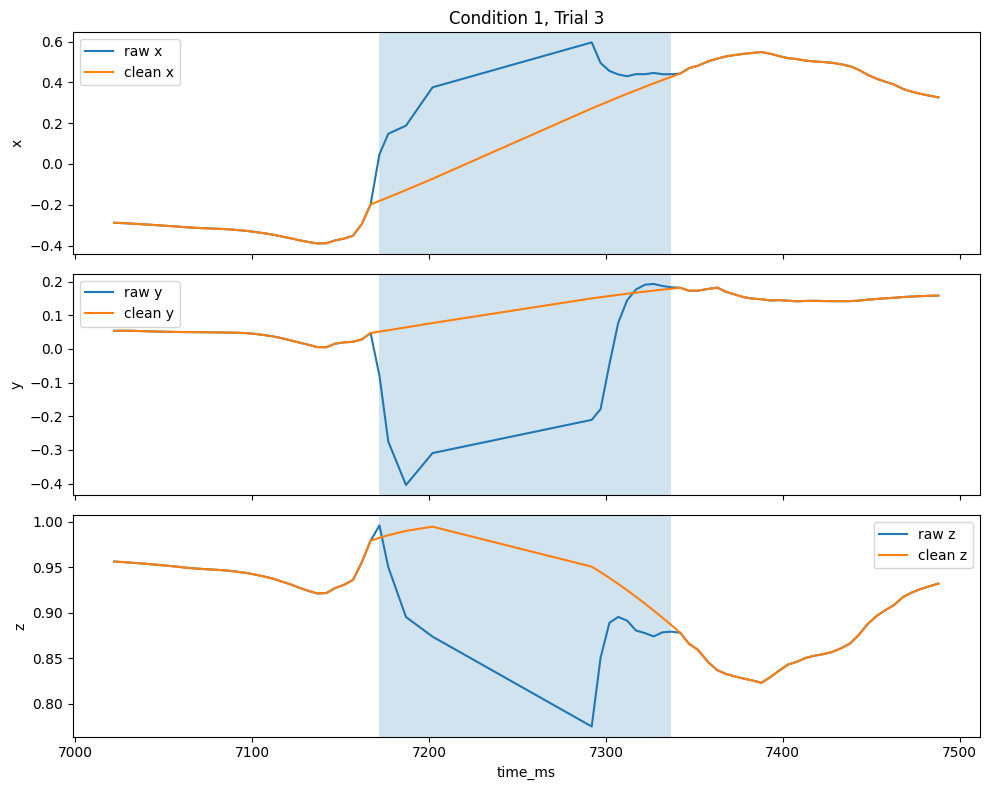

In [23]:
seg = (
    df_clean[(df_clean["condition_number"] == 1) &
             (df_clean["trial_number"] == 3)]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

runs = find_interpolated_runs(seg)
if runs:
    a, b = runs[0]
    plot_interpolation_xyz(seg, a, b, pad=30)

